In [206]:
import math
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import date
from scipy.stats import norm



In [207]:

data = yf.download("BHARTIARTL.NS", start="2025-03-01", end="2026-03-02",auto_adjust=True)
data = pd.DataFrame(data)
closing_prices = data["Close"]
daily_returns = closing_prices.pct_change()

[*********************100%***********************]  1 of 1 completed


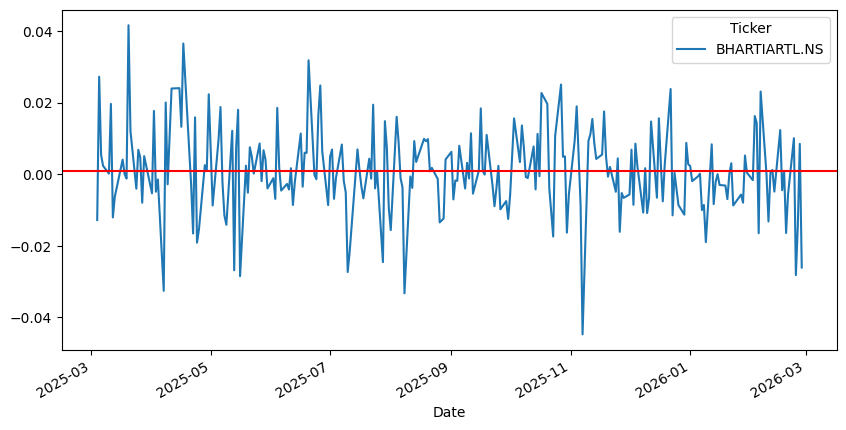

In [208]:
daily_returns = daily_returns.dropna()
daily_mean = daily_returns.mean()
daily_std = daily_returns.std()
annualized_std = daily_std * math.sqrt(252)
daily_returns.plot(figsize=(10,5))
plt.axhline(y=daily_mean.item(), color='r', label=f'Mean: {daily_mean.item():.2f}')
plt.show()

In [209]:
closing_prices.tail()

Ticker,BHARTIARTL.NS
Date,
2026-02-23,1997.300049
2026-02-24,1941.000000
2026-02-25,1913.400024
2026-02-26,1929.599976
2026-02-27,1879.300049


In [210]:
S0= 1879     #round(closing_prices.iloc[-1]).astype(int)#spot price at t
K = 1900 #strike price
r = 6.68/100
T1 = date(2026, 3,26 )
t0 = date(2026, 3, 3)
T = (T1-t0).days/252
print(T)



0.09126984126984126


In [211]:
d2 = ((math.log(S0/K) + (r - (0.5 * annualized_std.item()**2)) * T)) / (annualized_std.item() * math.sqrt(T))
print(d2)

-0.11554531707278322


In [212]:
d1 = d2 + (annualized_std.item() * math.sqrt(T))
print(d1)

-0.057585064113604034


In [213]:
P = (S0 * norm.cdf(d1)) - (math.exp(-r * T) * K * norm.cdf(d2))



In [214]:
print(f'The option price is:{P}')

The option price is:38.98829730236787


numpy.float64